In [1]:
# Cell 1: Imports
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("Libraries loaded")

Libraries loaded


In [4]:
# Cell 2: Set your data path
# EDIT THIS to match where YOUR data folder is!
# Example: r"C:\Users\YourName\Documents\data"

DATA_ROOT = Path(r"C:\Users\Arihant Bisen\Documents\data")

# The two PDT folders
pdt_1 = DATA_ROOT / "pdt_01-08"
pdt_2 = DATA_ROOT / "pdt_09-17"

# Quick check — do these folders exist?
print(f"pdt_01-08 exists: {pdt_1.exists()}")
print(f"pdt_09-17 exists: {pdt_2.exists()}")

# List what's inside pdt_01-08
if pdt_1.exists():
    print(f"\nFolders in pdt_01-08: {sorted([f.name for f in pdt_1.iterdir() if f.is_dir()])}")
if pdt_2.exists():
    print(f"Folders in pdt_09-17: {sorted([f.name for f in pdt_2.iterdir() if f.is_dir()])}")

pdt_01-08 exists: True
pdt_09-17 exists: True

Folders in pdt_01-08: ['01', '02', '03', '04', '05', '06', '07', '08']
Folders in pdt_09-17: ['09', '10', '11', '12', '13', '14', '15', '16', '17']


In [5]:
# Cell 3: Discover all .mat files across both pdt folders
# 
# WHY: Before we can train anything, we need to know exactly
#      what data we have. This cell builds a complete inventory.

inventory = []  # Will hold info about every .mat file we find

for pdt_folder in [pdt_1, pdt_2]:
    if not pdt_folder.exists():
        print(f"Folder not found: {pdt_folder}")
        continue
    
    # Loop through class folders (01, 02, ... 17)
    for class_dir in sorted(pdt_folder.iterdir()):
        if not class_dir.is_dir():
            continue
        
        # Get class number from folder name
        try:
            class_id = int(class_dir.name)
        except ValueError:
            continue  # Skip non-numeric folders
        
        # Look inside avt/ subfolder
        avt_dir = class_dir / "avt"
        if not avt_dir.exists():
            print(f"No avt/ folder in class {class_id:02d}")
            continue
        
        # Find all .mat files
        mat_files = sorted(avt_dir.glob("*.mat"))
        
        for mat_file in mat_files:
            # Skip the known bad file (paper says remove 03setup01.mat)
            if class_id == 3 and mat_file.name == "03setup01.mat":
                print(f"Skipping {mat_file.name} (excluded per paper)")
                continue
            
            # Extract setup number from filename like "02setup05.mat"
            setup_num = int(mat_file.stem.split("setup")[1])
            
            inventory.append({
                'class_id': class_id,
                'setup_id': setup_num,
                'file_path': mat_file,
                'file_name': mat_file.name,
            })

# Summary
print(f"\n{'='*50}")
print(f"INVENTORY COMPLETE")
print(f"{'='*50}")
print(f"Total .mat files found: {len(inventory)}")
print(f"Classes found: {sorted(set(item['class_id'] for item in inventory))}")
print(f"\nFiles per class:")
for cls in sorted(set(item['class_id'] for item in inventory)):
    count = sum(1 for item in inventory if item['class_id'] == cls)
    print(f"  Class {cls:02d}: {count} files")

Skipping 03setup01.mat (excluded per paper)

INVENTORY COMPLETE
Total .mat files found: 152
Classes found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Files per class:
  Class 01: 9 files
  Class 02: 9 files
  Class 03: 8 files
  Class 04: 9 files
  Class 05: 9 files
  Class 06: 9 files
  Class 07: 9 files
  Class 08: 9 files
  Class 09: 9 files
  Class 10: 9 files
  Class 11: 9 files
  Class 12: 9 files
  Class 13: 9 files
  Class 14: 9 files
  Class 15: 9 files
  Class 16: 9 files
  Class 17: 9 files


In [9]:
# Cell 4: Open ONE .mat file and see what's inside
#
# WHY: Before loading 152 files, let's understand the structure
#      of a single file first. What variables? What shape? What values?

# Pick the first file from our inventory
sample = inventory[0]
print(f"Opening: {sample['file_name']}")
print(f"Class: {sample['class_id']:02d}, Setup: {sample['setup_id']}")
print(f"Path: {sample['file_path']}")

# Load it
mat = sio.loadmat(str(sample['file_path']), squeeze_me=True)

# What variables are stored inside?
print(f"\n--- Variables inside the .mat file ---")
for key, val in mat.items():
    if key.startswith('__'):
        continue  # Skip MATLAB internal stuff
    if isinstance(val, np.ndarray):
        print(f"  '{key}': shape = {val.shape}, dtype = {val.dtype}")
    else:
        print(f"  '{key}': {type(val).__name__}")

# The actual sensor data
data = mat['data']
labels = mat['labelshulp']

print(f"\n--- The 'data' array ---")
print(f"  Shape: {data.shape}")
print(f"  = {data.shape[0]} time samples × {data.shape[1]} sensor channels")
print(f"  Values are in g's (acceleration due to gravity)")
print(f"  Range: {data.min():.6f} to {data.max():.6f}")

print(f"\n--- The 'labelshulp' array (sensor names) ---")
print(f"  {list(labels)}")
# print(f"  {len(labels)}") #

Opening: 01setup01.mat
Class: 01, Setup: 1
Path: C:\Users\Arihant Bisen\Documents\data\pdt_01-08\01\avt\01setup01.mat

--- Variables inside the .mat file ---
  'data': shape = (65530, 33), dtype = float64
  'labelshulp': shape = (33,), dtype = <U4

--- The 'data' array ---
  Shape: (65530, 33)
  = 65530 time samples × 33 sensor channels
  Values are in g's (acceleration due to gravity)
  Range: -0.001439 to 0.004372

--- The 'labelshulp' array (sensor names) ---
  [np.str_('99V '), np.str_('100V'), np.str_('101V'), np.str_('102V'), np.str_('103V'), np.str_('199L'), np.str_('199T'), np.str_('199V'), np.str_('200T'), np.str_('200V'), np.str_('201T'), np.str_('201V'), np.str_('202T'), np.str_('202V'), np.str_('203L'), np.str_('203T'), np.str_('203V'), np.str_('299V'), np.str_('300V'), np.str_('301V'), np.str_('302V'), np.str_('303V'), np.str_('511L'), np.str_('511T'), np.str_('511V'), np.str_('512L'), np.str_('512T'), np.str_('512V'), np.str_('R1V '), np.str_('R2L '), np.str_('R2T '), np.

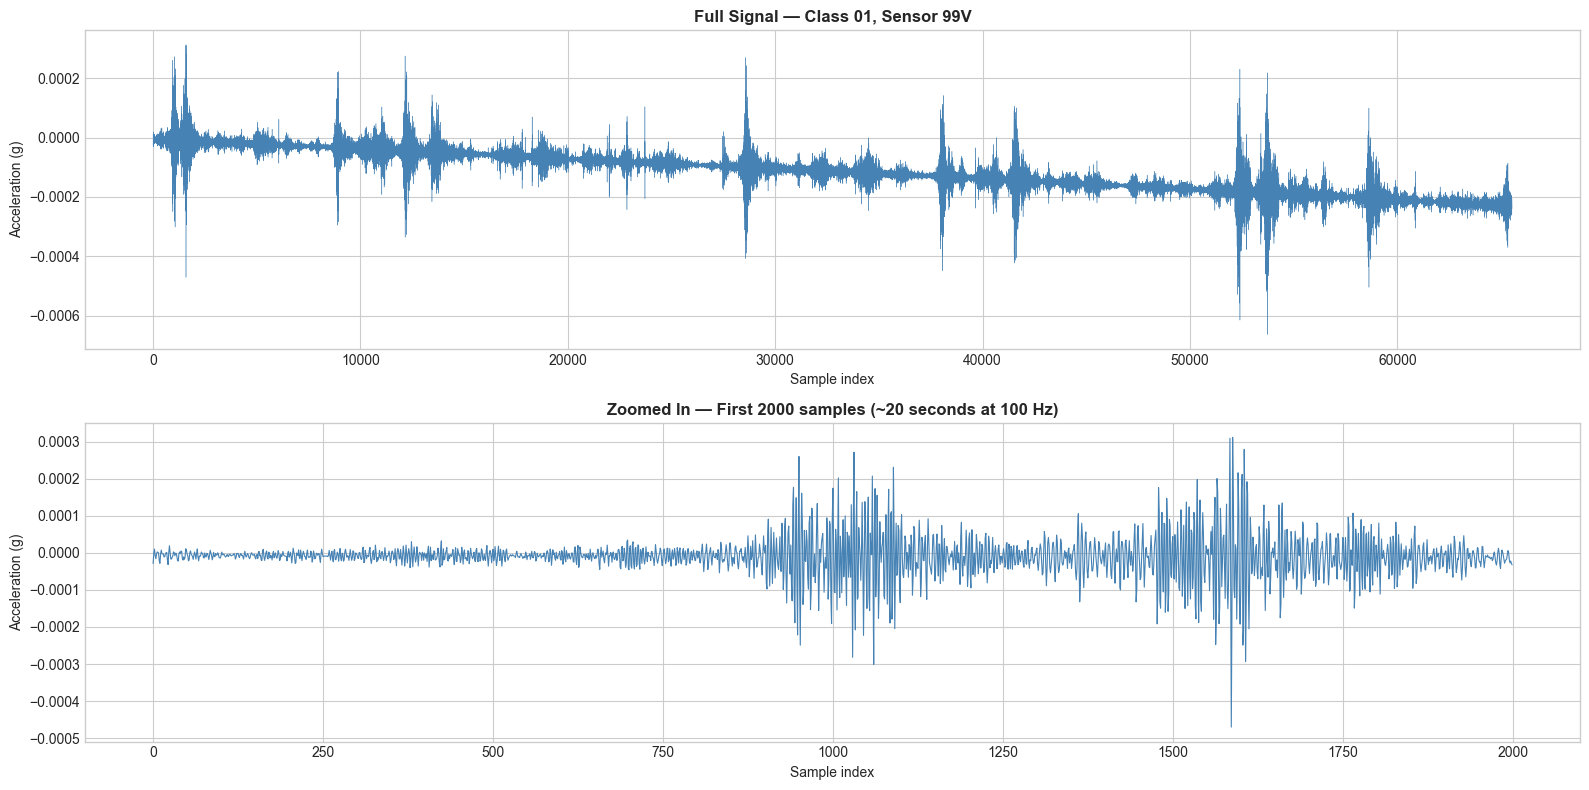

Sensor: 99V
Mean: -0.00011495 g
Std:  0.00007038 g
This is a very tiny vibration — the bridge barely moves!


In [10]:
# Cell 5: Plot the raw signal from one sensor
#
# WHY: Seeing the data helps you build intuition.
#      A healthy bridge has small, regular vibrations.
#      A damaged bridge vibrates differently.

signal = data[:, 0]  # First sensor column
sensor_name = labels[0].strip()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top: full signal
axes[0].plot(signal, linewidth=0.3, color='steelblue')
axes[0].set_title(f'Full Signal — Class {sample["class_id"]:02d}, Sensor {sensor_name}', 
                   fontweight='bold')
axes[0].set_ylabel('Acceleration (g)')
axes[0].set_xlabel('Sample index')

# Bottom: zoomed in to first 2000 samples
axes[1].plot(signal[:2000], linewidth=0.8, color='steelblue')
axes[1].set_title(f'Zoomed In — First 2000 samples (~20 seconds at 100 Hz)', 
                   fontweight='bold')
axes[1].set_ylabel('Acceleration (g)')
axes[1].set_xlabel('Sample index')

plt.tight_layout()
plt.show()

print(f"Sensor: {sensor_name}")
print(f"Mean: {signal.mean():.8f} g")
print(f"Std:  {signal.std():.8f} g")
print(f"This is a very tiny vibration — the bridge barely moves!")

In [15]:
# Cell 6: Load one file from EACH class and compare
#
# WHY: This is the whole point — can we SEE a difference
#      between healthy and damaged vibrations? If yes,
#      then a neural network can definitely learn it.

# Pick one file from each class (setup 02 to be safe — all classes have it)
class_samples = {}

for item in inventory:
    cls = item['class_id']
    if cls not in class_samples and item['setup_id'] == 2:
        mat = sio.loadmat(str(item['file_path']), squeeze_me=True)
        class_samples[cls] = {
            'data': mat['data'],
            'labels': mat['labelshulp'],
            'class_id': cls,
        }

print(f"Loaded setup 02 from {len(class_samples)} classes")
print(f"Classes: {sorted(class_samples.keys())}")

Loaded setup 02 from 17 classes
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


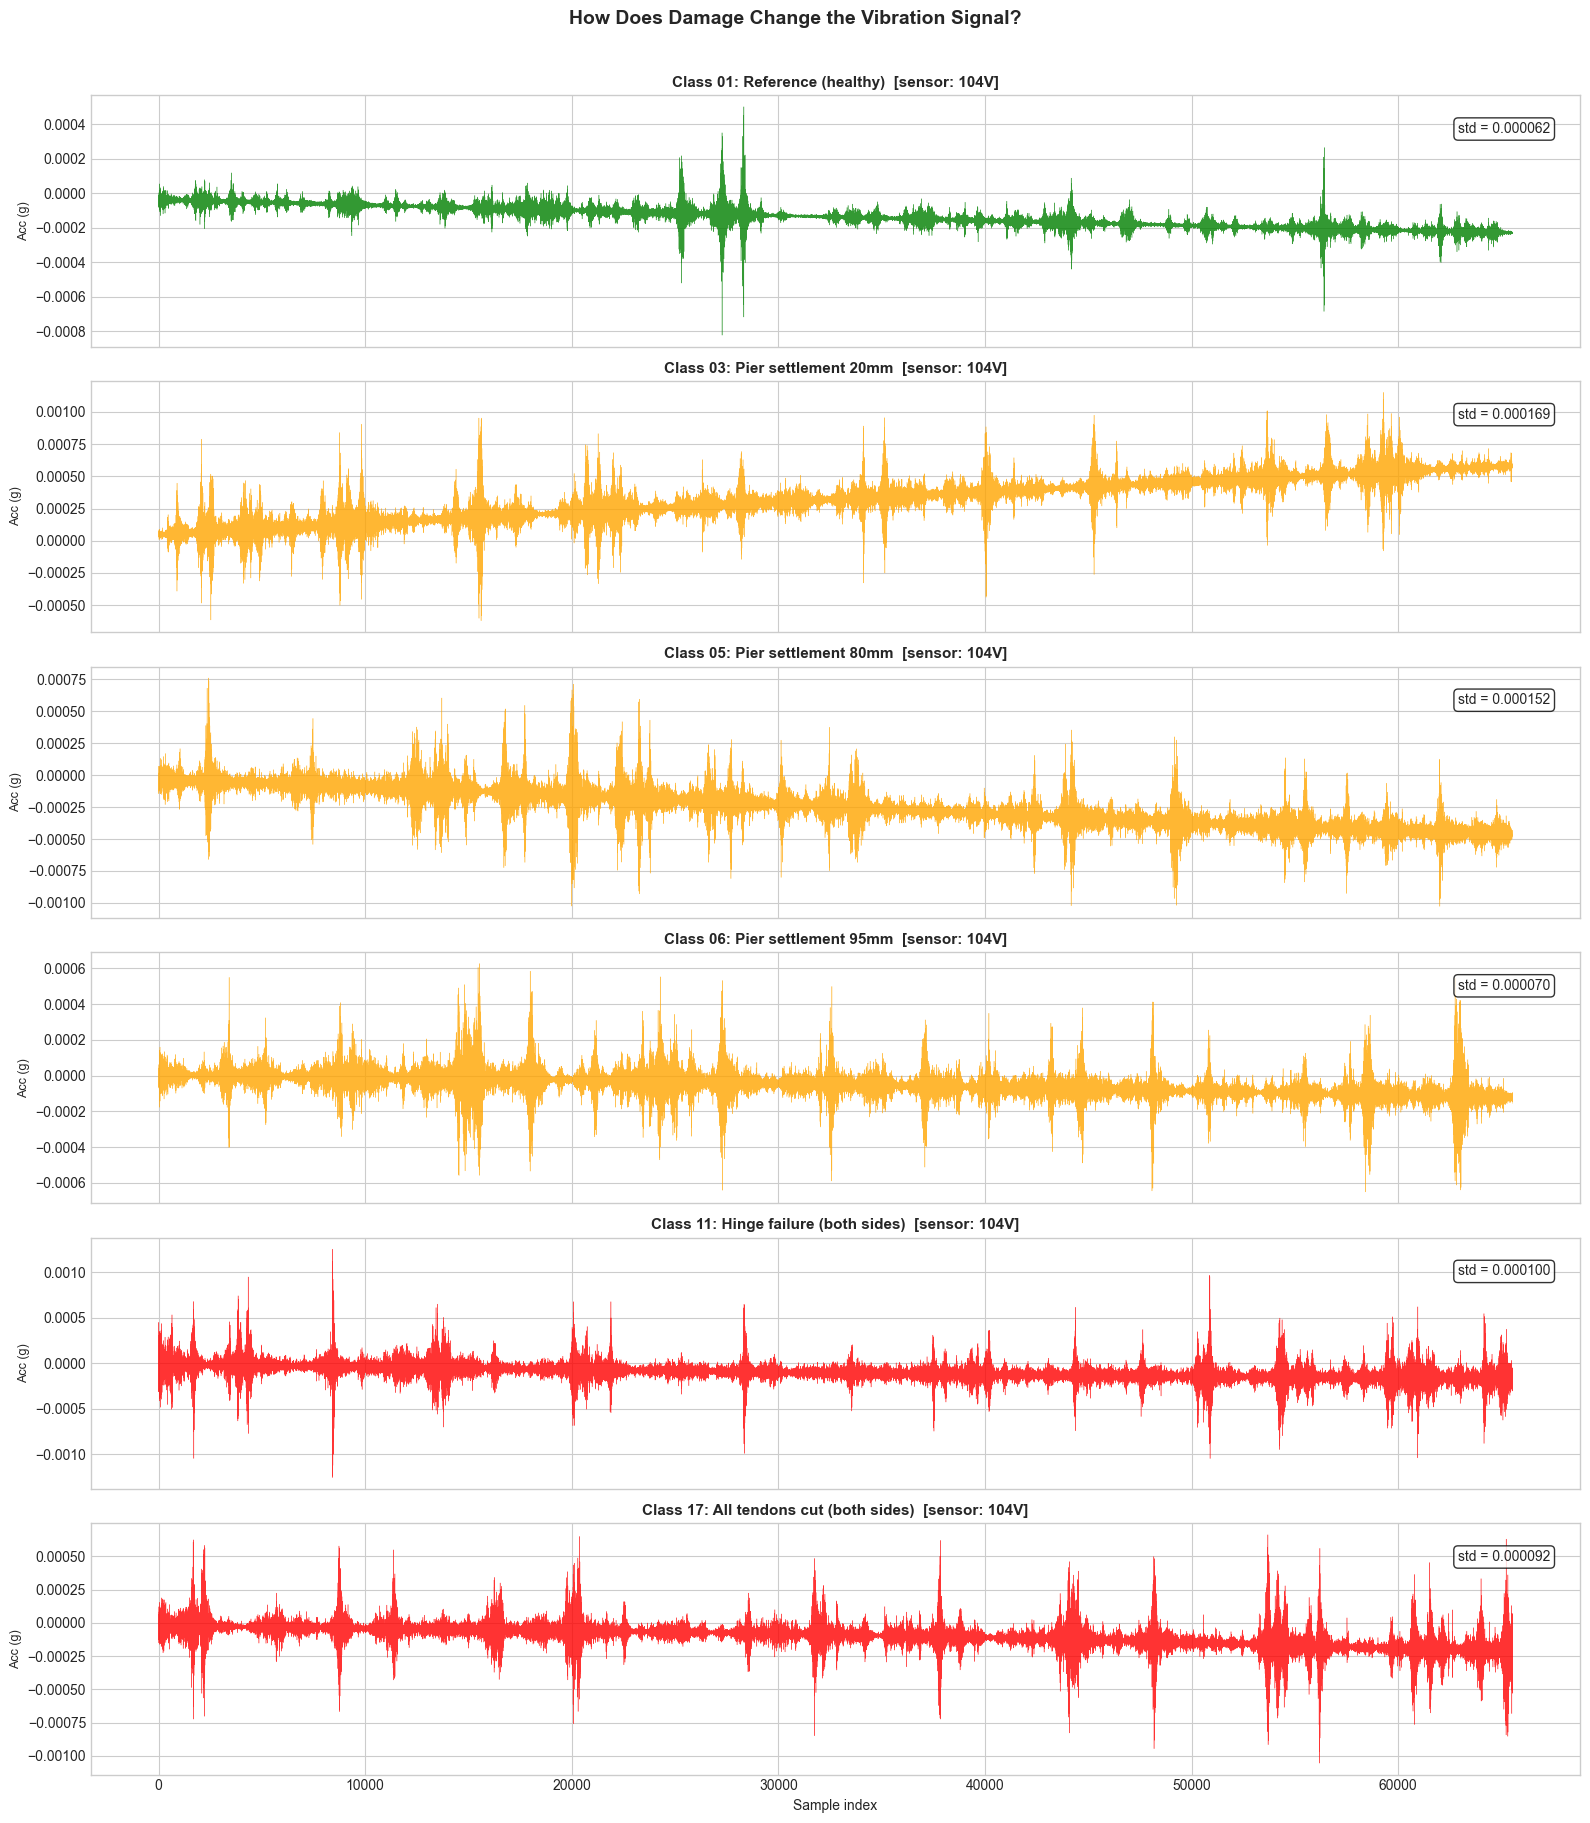

In [12]:
# Cell 7: Visual comparison — healthy vs increasingly damaged
#
# WHY: If the signals look different to your eyes, the AI
#      will have no problem learning the difference.

# Damage class descriptions (from the Z24 experiment)
damage_names = {
    1: "Reference (healthy)",
    2: "Reference (after repair)",
    3: "Pier settlement 20mm",
    4: "Pier settlement 40mm",
    5: "Pier settlement 80mm",
    6: "Pier settlement 95mm",
    7: "Foundation tilt",
    8: "Concrete spalling",
    9: "Landslide at abutment",
    10: "Hinge failure (one side)",
    11: "Hinge failure (both sides)",
    12: "Anchor head failure",
    13: "2 anchor heads failed",
    14: "Rupture of 2 tendons",
    15: "Rupture of 4 tendons",
    16: "All tendons cut (one side)",
    17: "All tendons cut (both sides)",
}

# Show 6 classes: healthy + progressive damage
show_classes = [1, 3, 5, 6, 11, 17]

fig, axes = plt.subplots(len(show_classes), 1, figsize=(16, 3 * len(show_classes)), 
                          sharex=True)

for i, cls in enumerate(show_classes):
    if cls not in class_samples:
        axes[i].text(0.5, 0.5, f'Class {cls} not loaded', transform=axes[i].transAxes)
        continue
    
    # Use the LAST column that's common-ish — or just column 0
    signal = class_samples[cls]['data'][:, 0]
    sensor = class_samples[cls]['labels'][0].strip()
    
    color = 'green' if cls <= 2 else 'orange' if cls <= 6 else 'red'
    
    axes[i].plot(signal, linewidth=0.3, color=color, alpha=0.8)
    axes[i].set_ylabel('Acc (g)', fontsize=9)
    axes[i].set_title(f'Class {cls:02d}: {damage_names[cls]}  [sensor: {sensor}]',
                      fontsize=11, fontweight='bold')
    
    # Show the std value as a measure of vibration intensity
    axes[i].text(0.98, 0.85, f'std = {signal.std():.6f}', 
                transform=axes[i].transAxes, fontsize=10,
                ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[-1].set_xlabel('Sample index')
fig.suptitle('How Does Damage Change the Vibration Signal?', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Cell 8: Check which sensors are in each setup
#
# WHY: Setup 01 has sensors 99V, 100V, 101V...
#      Setup 05 has sensors 119V, 120V, 121V...
#      We need to figure out: are ANY sensors the same across ALL setups?
#      Those "common" sensors are the ones we should train on.

# Load labels from every setup of class 01
print("Checking sensor consistency across setups (using Class 01):\n")

class_01_files = [item for item in inventory if item['class_id'] == 1]

all_sensor_sets = {}
for item in class_01_files:
    mat = sio.loadmat(str(item['file_path']), squeeze_me=True)
    sensors = [s.strip() for s in mat['labelshulp']]
    all_sensor_sets[item['setup_id']] = set(sensors)
    print(f"  Setup {item['setup_id']:02d}: {len(sensors)} sensors → {sensors[:5]}... ")

# Find sensors that appear in ALL setups
common_sensors = all_sensor_sets[class_01_files[0]['setup_id']]
for setup_id, sensor_set in all_sensor_sets.items():
    common_sensors = common_sensors.intersection(sensor_set)

print(f"\n{'='*50}")
print(f"Sensors present in ALL {len(all_sensor_sets)} setups:")
print(f"  {sorted(common_sensors)}")
print(f"  Count: {len(common_sensors)}")
print(f"\nThese are the REFERENCE sensors — always plugged in!")

Checking sensor consistency across setups (using Class 01):

  Setup 01: 33 sensors → ['99V', '100V', '101V', '102V', '103V']... 
  Setup 02: 33 sensors → ['104V', '105V', '106V', '107V', '108V']... 
  Setup 03: 33 sensors → ['109V', '110V', '111V', '112V', '113V']... 
  Setup 04: 33 sensors → ['114V', '115V', '116V', '117V', '118V']... 
  Setup 05: 27 sensors → ['119V', '120V', '121V', '122V', '123V']... 
  Setup 06: 33 sensors → ['124V', '125V', '126V', '127V', '128V']... 
  Setup 07: 31 sensors → ['129V', '130V', '131V', '132V', '133V']... 
  Setup 08: 33 sensors → ['134V', '135V', '136V', '137V', '138V']... 
  Setup 09: 33 sensors → ['139V', '140V', '141V', '142V', '143V']... 

Sensors present in ALL 9 setups:
  ['R1V', 'R2L', 'R2T', 'R2V', 'R3V']
  Count: 5

These are the REFERENCE sensors — always plugged in!


In [18]:
# Cell 10: Load ALL data — every sensor from every file
#
# WHY: We're building two arrays:
#   X = all the signals (each row = one sensor's 65530 values)
#   y = the damage class label for each signal
#
# Think of it like a spreadsheet:
#   Row 1: [sensor 99V from class 01 setup 01]  → label: 1
#   Row 2: [sensor 100V from class 01 setup 01] → label: 1
#   ...
#   Row N: [sensor R3V from class 17 setup 09]  → label: 17

X_all = []      # Will become a big 2D array of signals
y_all = []      # Damage class for each signal
meta_all = []   # Extra info to track where each sample came from

for i, item in enumerate(inventory):
    # Load the .mat file
    mat = sio.loadmat(str(item['file_path']), squeeze_me=True)
    data = mat['data']           # shape: (65530, num_sensors)
    labels = mat['labelshulp']   # sensor names
    
    # Each column (sensor channel) becomes one training sample
    for col_idx in range(data.shape[1]):
        signal = data[:, col_idx]          # shape: (65530,)
        sensor_name = labels[col_idx].strip()
        
        X_all.append(signal)
        y_all.append(item['class_id'])
        meta_all.append({
            'class_id': item['class_id'],
            'setup_id': item['setup_id'],
            'sensor': sensor_name,
            'file': item['file_name'],
        })
    
    # Progress indicator (every 20 files)
    if (i + 1) % 20 == 0 or i == len(inventory) - 1:
        print(f"  Loaded {i+1}/{len(inventory)} files...")

# Convert to numpy arrays
X_all = np.array(X_all, dtype=np.float64)
y_all = np.array(y_all, dtype=np.int32)

print(f"\n{'='*50}")
print(f"DATA LOADING COMPLETE")
print(f"{'='*50}")
print(f"X shape: {X_all.shape}")
print(f"  → {X_all.shape[0]} samples, each with {X_all.shape[1]} time points")
print(f"y shape: {y_all.shape}")
print(f"  → {y_all.shape[0]} labels")
print(f"\nClass distribution:")
for cls in sorted(set(y_all)):
    count = np.sum(y_all == cls)
    print(f"  Class {cls:02d}: {count:4d} samples — {damage_names[cls]}")

  Loaded 20/152 files...
  Loaded 40/152 files...
  Loaded 60/152 files...
  Loaded 80/152 files...
  Loaded 100/152 files...
  Loaded 120/152 files...
  Loaded 140/152 files...
  Loaded 152/152 files...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4912,) + inhomogeneous part.

In [19]:
# Cell 10b: Check which signals have different lengths
#
# WHY: numpy can't make a 2D array if rows have different lengths.
#      Let's find out what lengths exist.

lengths = [len(x) for x in X_all]
unique_lengths = set(lengths)

print(f"Total signals: {len(X_all)}")
print(f"Unique signal lengths: {unique_lengths}")

for length in sorted(unique_lengths):
    count = lengths.count(length)
    # Find an example
    idx = lengths.index(length)
    example = meta_all[idx]
    print(f"  Length {length}: {count} signals (e.g. class {example['class_id']:02d}, "
          f"setup {example['setup_id']:02d}, sensor {example['sensor']})")

Total signals: 4912
Unique signal lengths: {65536, 65530, 65410}
  Length 65410: 33 signals (e.g. class 07, setup 01, sensor 99V)
  Length 65530: 580 signals (e.g. class 01, setup 01, sensor 99V)
  Length 65536: 4299 signals (e.g. class 03, setup 02, sensor 104V)


In [20]:
# Cell 10c: Trim all signals to the same length and build arrays
#
# WHY: All signals need the same length to form a 2D numpy array.
#      We cut to the shortest (65410). That's only 0.2% data loss — negligible.

min_length = min(len(x) for x in X_all)
print(f"Trimming all signals to {min_length} samples")

# Trim each signal
X_all_trimmed = [x[:min_length] for x in X_all]

# NOW convert to numpy arrays
X_all = np.array(X_all_trimmed, dtype=np.float64)
y_all = np.array(y_all, dtype=np.int32)

print(f"\n{'='*50}")
print(f"DATA LOADING COMPLETE")
print(f"{'='*50}")
print(f"X shape: {X_all.shape}")
print(f"  → {X_all.shape[0]} samples, each with {X_all.shape[1]} time points")
print(f"y shape: {y_all.shape}")
print(f"  → {y_all.shape[0]} labels")
print(f"\nClass distribution:")
for cls in sorted(set(y_all)):
    count = np.sum(y_all == cls)
    print(f"  Class {cls:02d}: {count:4d} samples — {damage_names[cls]}")

Trimming all signals to 65410 samples

DATA LOADING COMPLETE
X shape: (4912, 65410)
  → 4912 samples, each with 65410 time points
y shape: (4912,)
  → 4912 labels

Class distribution:
  Class 01:  289 samples — Reference (healthy)
  Class 02:  291 samples — Reference (after repair)
  Class 03:  258 samples — Pier settlement 20mm
  Class 04:  291 samples — Pier settlement 40mm
  Class 05:  291 samples — Pier settlement 80mm
  Class 06:  291 samples — Pier settlement 95mm
  Class 07:  291 samples — Foundation tilt
  Class 08:  291 samples — Concrete spalling
  Class 09:  291 samples — Landslide at abutment
  Class 10:  291 samples — Hinge failure (one side)
  Class 11:  291 samples — Hinge failure (both sides)
  Class 12:  291 samples — Anchor head failure
  Class 13:  291 samples — 2 anchor heads failed
  Class 14:  291 samples — Rupture of 2 tendons
  Class 15:  291 samples — Rupture of 4 tendons
  Class 16:  291 samples — All tendons cut (one side)
  Class 17:  291 samples — All tendo

In [23]:
pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/332.0 MB 5.7 MB/s eta 0:00:58
   ---------------------------------------- 1.3/332.0 MB 3.7 MB/s eta 0:01:29
   ---------------------------------------- 2.4/332.0 MB 4.4 MB/s eta 0:01:16
   ---------------------------------------- 3.4/332.0 MB 4.6 MB/s eta 0:01:13
    --------------------------------------- 4.7/332.0 MB 4.9 MB/s eta 0:01:07
    --------------------------------------- 5.5/332.0 MB 4.9 MB/s eta 0:01:07
    --------------------------------------- 6.6/332.0 MB 4.9 MB/s eta 0:01:07
    -------------

In [2]:
# Cell 11: Check if your GPU is ready for training
#
# WHY: Better to find out NOW if CUDA is working than to discover
#      problems when we start training in Phase 2.

# Check TensorFlow GPU
try:
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            print(f"  ✅ GPU found: {gpu.name}")
        # Show GPU memory
        print(f"  GPU details: {tf.config.experimental.get_device_details(gpus[0])}")
    else:
        print("  ❌ No GPU detected by TensorFlow")
        print("  Training will work on CPU but will be much slower")
except ImportError:
    print("  ⚠️ TensorFlow not installed yet")
    print("  Install with: pip install tensorflow")

print()

# Check PyTorch GPU (in case we need it)
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  ✅ GPU: {torch.cuda.get_device_name(0)}")
        mem = torch.cuda.get_device_properties(0).total_memory
except ImportError:
    print("  ⚠️ PyTorch not installed")

TensorFlow version: 2.20.0
  ❌ No GPU detected by TensorFlow
  Training will work on CPU but will be much slower

PyTorch version: 2.9.1+cu130
  CUDA available: True
  ✅ GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU Memory: {mem:.1f} GB")

✅ GPU: NVIDIA GeForce RTX 5050 Laptop GPU
GPU Memory: 8.0 GB


In [25]:
# Cell 12: Split data into train / validation / test
#
# ⚠️ IMPORTANT: We split BY SETUP, not randomly!
#
# WHY: If we randomly split, sensor 99V from class 01 setup 01
#      might end up in TRAIN, while sensor 100V from the SAME file
#      ends up in TEST. Those signals were recorded at the EXACT
#      same time on the SAME bridge — they're correlated!
#      The model would "cheat" by recognizing the recording session,
#      not the actual damage pattern. This is called DATA LEAKAGE.
#
# CORRECT approach: Split by SETUP NUMBER
#   Train:      setups 1-6  (67% of data)
#   Validation: setups 7-8  (22% of data)  
#   Test:       setup 9     (11% of data)
#
# This way, the model is tested on recordings it has NEVER seen.

train_setups = [1, 2, 3, 4, 5, 6]
val_setups   = [7, 8]
test_setups  = [9]

# Get setup ID for each sample from our metadata
setup_ids = np.array([m['setup_id'] for m in meta_all])

# Create masks
train_mask = np.isin(setup_ids, train_setups)
val_mask   = np.isin(setup_ids, val_setups)
test_mask  = np.isin(setup_ids, test_setups)

# Split
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"{'='*50}")
print(f"SPLIT BY SETUP (no data leakage!)")
print(f"{'='*50}")
print(f"Train:      {X_train.shape[0]:4d} samples (setups {train_setups})")
print(f"Validation: {X_val.shape[0]:4d} samples (setups {val_setups})")
print(f"Test:       {X_test.shape[0]:4d} samples (setups {test_setups})")
print(f"Total:      {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:4d}")

# Verify each split has all 17 classes
print(f"\nClasses in train: {sorted(set(y_train))}")
print(f"Classes in val:   {sorted(set(y_val))}")
print(f"Classes in test:  {sorted(set(y_test))}")

# Quick sanity check
print(f"\nSanity check — no overlap?")
train_files = set(meta_all[i]['file'] for i in range(len(meta_all)) if train_mask[i])
test_files  = set(meta_all[i]['file'] for i in range(len(meta_all)) if test_mask[i])
overlap = train_files.intersection(test_files)
print(f"  Files in both train AND test: {len(overlap)} {'✅ (none — good!)' if len(overlap)==0 else '❌ LEAKAGE!'}")

SPLIT BY SETUP (no data leakage!)
Train:      3231 samples (setups [1, 2, 3, 4, 5, 6])
Validation: 1120 samples (setups [7, 8])
Test:        561 samples (setups [9])
Total:      4912

Classes in train: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17)]
Classes in val:   [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17)]
Classes in test:  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17)]

Sanity check — no overlap?
  Files in both train AND test: 0 ✅ (none — 

In [26]:
# Cell 13: Look at the raw signal statistics BEFORE normalization
#
# WHY: Neural networks learn best when input values are small and
#      centered around zero. Let's see what our raw data looks like.

print("Raw signal statistics (first 5 training samples):\n")
for i in range(5):
    signal = X_train[i]
    sensor = meta_all[np.where(train_mask)[0][i]]['sensor']
    cls = y_train[i]
    print(f"  Class {cls:02d}, {sensor:>5s}: "
          f"mean={signal.mean():>12.8f}  std={signal.std():>10.8f}  "
          f"min={signal.min():>12.8f}  max={signal.max():>12.8f}")

print(f"\nOverall across ALL training data:")
print(f"  Global mean: {X_train.mean():.8f}")
print(f"  Global std:  {X_train.std():.8f}")
print(f"  Global min:  {X_train.min():.8f}")
print(f"  Global max:  {X_train.max():.8f}")

print(f"\n⚠️ Problem: values are TINY (order of 0.0001)")
print(f"   Neural networks struggle with such small numbers.")
print(f"   Also, different sensors have different scales.")
print(f"   Solution: Z-score normalization (subtract mean, divide by std)")

Raw signal statistics (first 5 training samples):

  Class 01,   99V: mean= -0.00011474  std=0.00007027  min= -0.00066251  max=  0.00031171
  Class 01,  100V: mean=  0.00001824  std=0.00003842  min= -0.00043080  max=  0.00048832
  Class 01,  101V: mean= -0.00000434  std=0.00002238  min= -0.00034838  max=  0.00032657
  Class 01,  102V: mean=  0.00000655  std=0.00002506  min= -0.00037125  max=  0.00037019
  Class 01,  103V: mean=  0.00148166  std=0.00004448  min=  0.00077156  max=  0.00202111

Overall across ALL training data:
  Global mean: -0.00015356
  Global std:  0.00225923
  Global min:  -0.01771912
  Global max:  0.07096051

⚠️ Problem: values are TINY (order of 0.0001)
   Neural networks struggle with such small numbers.
   Also, different sensors have different scales.
   Solution: Z-score normalization (subtract mean, divide by std)


Normalization stats (from training data only):
  mean = -0.0001535632
  std  = 0.0022592254

After normalization:
  Train — mean: 0.000000, std: 1.000000
  Val   — mean: 0.325790, std: 6.000893
  Test  — mean: 0.170548, std: 1.862486


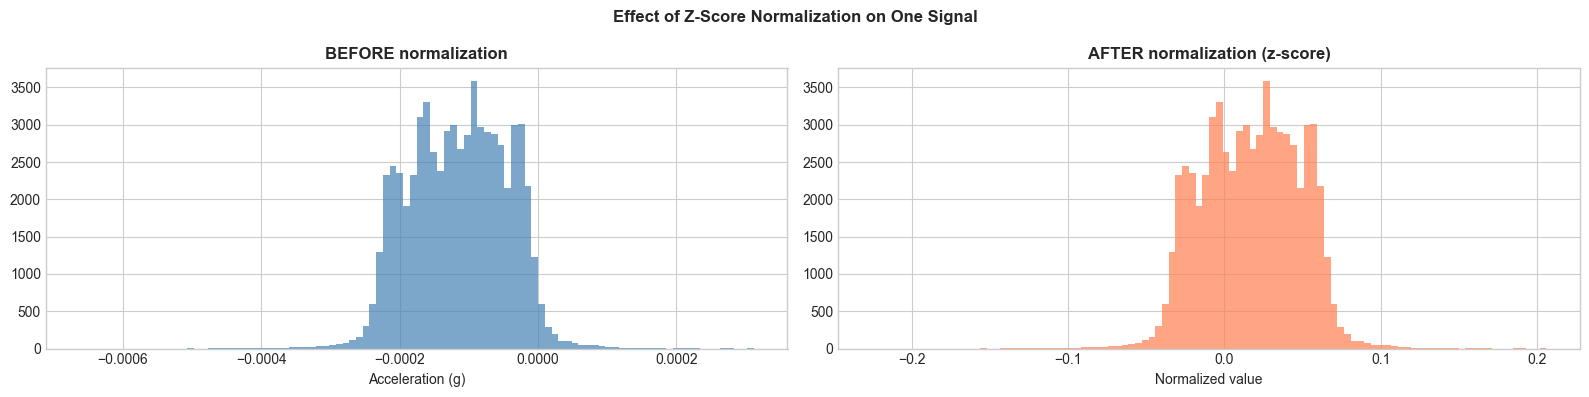


✅ Data is now normalized and ready for model training


In [27]:
# Cell 14: Z-score normalize the data
#
# HOW IT WORKS:
#   For each sample: normalized = (signal - mean) / std
#   After this, every signal has mean≈0 and std≈1
#
# CRITICAL RULE: We compute mean & std from TRAINING data only,
#   then apply the SAME values to val and test.
#   If we used test data to compute the stats, that would be
#   another form of data leakage (peeking at the test set).

# Compute stats from training data only
train_mean = X_train.mean()
train_std = X_train.std()

print(f"Normalization stats (from training data only):")
print(f"  mean = {train_mean:.10f}")
print(f"  std  = {train_std:.10f}")

# Apply to all three splits
X_train_norm = (X_train - train_mean) / train_std
X_val_norm   = (X_val   - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

# Verify
print(f"\nAfter normalization:")
print(f"  Train — mean: {X_train_norm.mean():.6f}, std: {X_train_norm.std():.6f}")
print(f"  Val   — mean: {X_val_norm.mean():.6f}, std: {X_val_norm.std():.6f}")
print(f"  Test  — mean: {X_test_norm.mean():.6f}, std: {X_test_norm.std():.6f}")

# Check a sample before and after
sample_idx = 0
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(X_train[sample_idx], bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('BEFORE normalization', fontweight='bold')
axes[0].set_xlabel('Acceleration (g)')

axes[1].hist(X_train_norm[sample_idx], bins=100, color='coral', alpha=0.7)
axes[1].set_title('AFTER normalization (z-score)', fontweight='bold')
axes[1].set_xlabel('Normalized value')

plt.suptitle('Effect of Z-Score Normalization on One Signal', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ Data is now normalized and ready for model training")

In [28]:
# Cell 15: Per-sample normalization (each signal normalized independently)
#
# WHY: With global normalization, a sensor that naturally vibrates more
#      (like one at mid-span) gets huge normalized values, while a quiet
#      sensor near the pier gets tiny values. Per-sample normalization
#      puts EVERY signal on the same scale regardless of sensor position.
#
# This is like grading on a curve — each signal is compared to itself.

def normalize_per_sample(X):
    """Normalize each row (signal) to have mean=0, std=1"""
    means = X.mean(axis=1, keepdims=True)    # mean of each row
    stds  = X.std(axis=1, keepdims=True)     # std of each row
    stds[stds == 0] = 1  # avoid division by zero for dead sensors
    return (X - means) / stds

X_train_norm = normalize_per_sample(X_train)
X_val_norm   = normalize_per_sample(X_val)
X_test_norm  = normalize_per_sample(X_test)

print("After PER-SAMPLE normalization:")
print(f"  Train — mean: {X_train_norm.mean():.6f}, std: {X_train_norm.std():.6f}")
print(f"  Val   — mean: {X_val_norm.mean():.6f}, std: {X_val_norm.std():.6f}")
print(f"  Test  — mean: {X_test_norm.mean():.6f}, std: {X_test_norm.std():.6f}")

# Verify individual samples
print(f"\nSample-level check (first 3 training samples):")
for i in range(3):
    s = X_train_norm[i]
    print(f"  Sample {i}: mean={s.mean():.6f}, std={s.std():.6f}")

print(f"\n✅ Every signal now has mean≈0 and std≈1")
print(f"   No data leakage — each signal normalized using only its own values")

After PER-SAMPLE normalization:
  Train — mean: -0.000000, std: 1.000000
  Val   — mean: 0.000000, std: 1.000000
  Test  — mean: 0.000000, std: 1.000000

Sample-level check (first 3 training samples):
  Sample 0: mean=-0.000000, std=1.000000
  Sample 1: mean=0.000000, std=1.000000
  Sample 2: mean=0.000000, std=1.000000

✅ Every signal now has mean≈0 and std≈1
   No data leakage — each signal normalized using only its own values


In [29]:
# Cell 16: Reshape data for model input
#
# WHY: Right now X_train_norm has shape (samples, 65410)
#      But neural networks expect a CHANNEL dimension:
#        WaveNet needs: (samples, timesteps, channels)
#        So shape becomes: (samples, 65410, 1)
#      The "1" means we have 1 input channel per sample
#      (like mono audio vs stereo)

X_train_final = X_train_norm[..., np.newaxis]  # adds a dimension at the end
X_val_final   = X_val_norm[..., np.newaxis]
X_test_final  = X_test_norm[..., np.newaxis]

print(f"Final shapes for model input:")
print(f"  X_train: {X_train_final.shape}")
print(f"  X_val:   {X_val_final.shape}")
print(f"  X_test:  {X_test_final.shape}")
print(f"  y_train: {y_train.shape}  (labels: {sorted(set(y_train))})")

print(f"\nWhat the model will see:")
print(f"  Input:  one signal of {X_train_final.shape[1]} time steps, {X_train_final.shape[2]} channel")
print(f"  Output: predict which of {len(set(y_train))} damage classes it belongs to")

Final shapes for model input:
  X_train: (3231, 65410, 1)
  X_val:   (1120, 65410, 1)
  X_test:  (561, 65410, 1)
  y_train: (3231,)  (labels: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17)])

What the model will see:
  Input:  one signal of 65410 time steps, 1 channel
  Output: predict which of 17 damage classes it belongs to


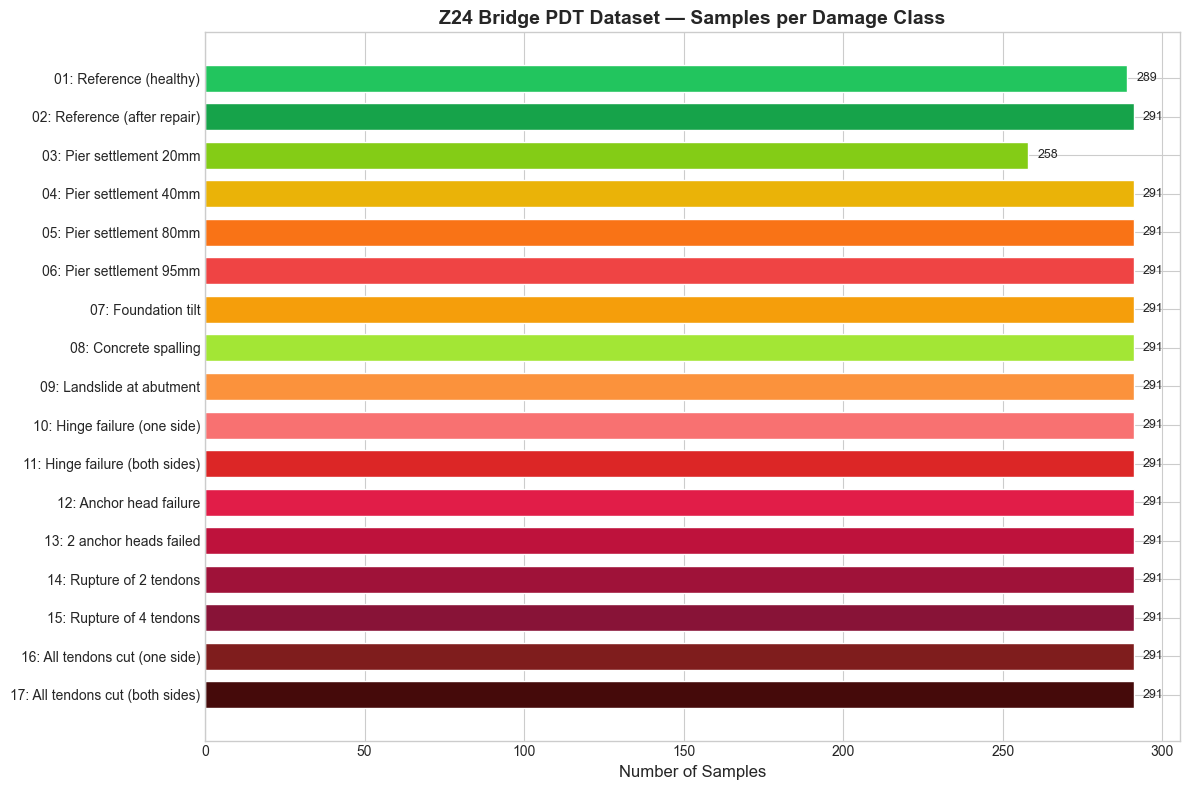

📊 Saved: fig_dataset_distribution.png


In [33]:
# Cell 16b: Dataset structure visualization
#
# Shows: how many samples per class, color-coded by damage severity

severity_colors = {
    1: '#22c55e', 2: '#16a34a',          # green = healthy
    3: '#84cc16', 4: '#eab308',           # yellow-green = minor
    5: '#f97316', 6: '#ef4444',           # orange-red = settlement
    7: '#f59e0b', 8: '#a3e635', 9: '#fb923c',  # mixed damage types
    10: '#f87171', 11: '#dc2626',         # red = hinge failure
    12: '#e11d48', 13: '#be123c',         # dark red = tendon
    14: '#9f1239', 15: '#881337',
    16: '#7f1d1d', 17: '#450a0a',         # very dark = extreme
}

classes = sorted(set(y_all))
counts = [np.sum(y_all == c) for c in classes]
colors = [severity_colors[c] for c in classes]
labels = [f"{c:02d}: {damage_names[c]}" for c in classes]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(classes)), counts, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_title('Z24 Bridge PDT Dataset — Samples per Damage Class', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels on bars
for i, count in enumerate(counts):
    ax.text(count + 3, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_dataset_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("📊 Saved: fig_dataset_distribution.png")

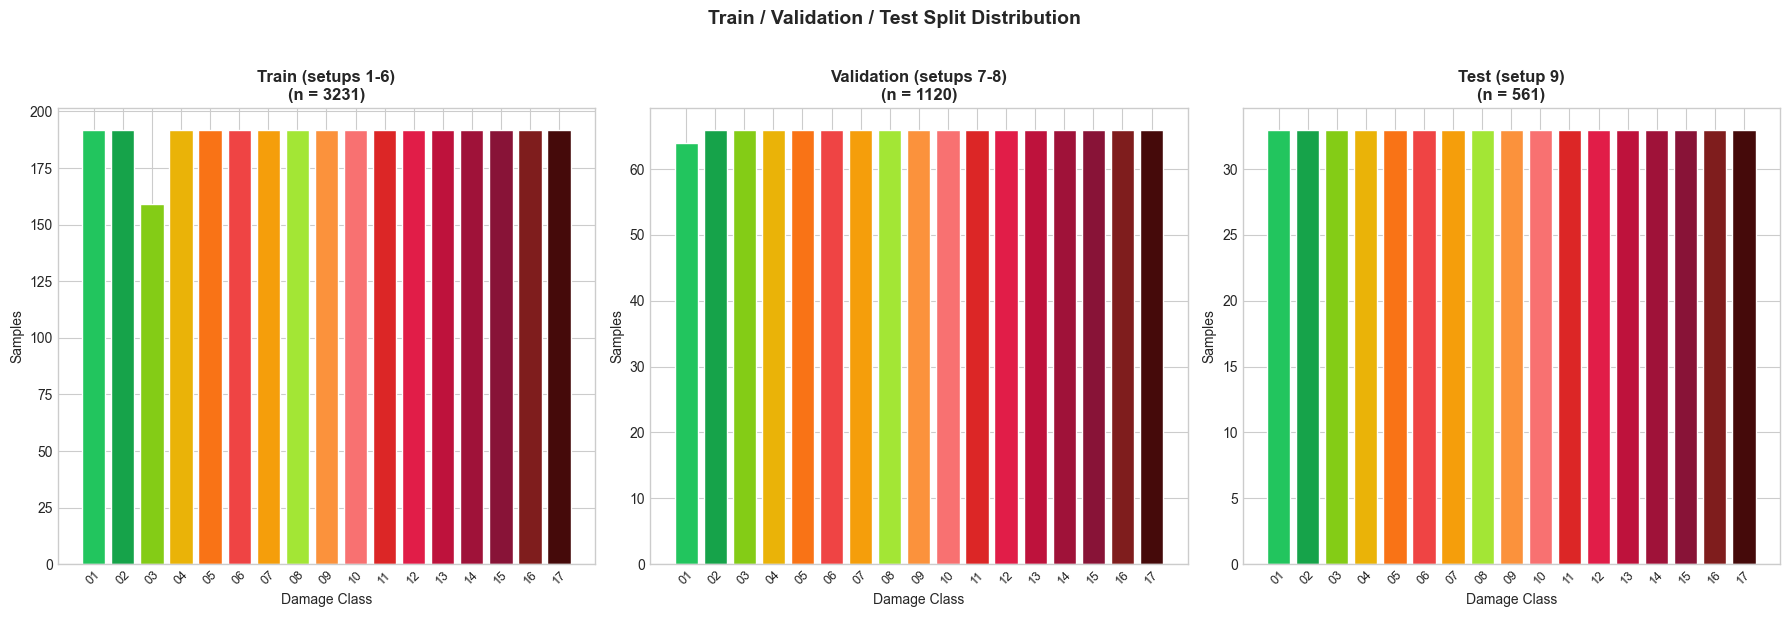

📊 Saved: fig_split_distribution.png


In [34]:
# Cell 16c: Split distribution — show all 3 splits side by side

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, y_data) in zip(axes, 
    [('Train (setups 1-6)', y_train), 
     ('Validation (setups 7-8)', y_val), 
     ('Test (setup 9)', y_test)]):
    
    classes_in = sorted(set(y_data))
    counts_in = [np.sum(y_data == c) for c in classes_in]
    colors_in = [severity_colors[c] for c in classes_in]
    
    ax.bar(range(len(classes_in)), counts_in, color=colors_in, edgecolor='white')
    ax.set_xticks(range(len(classes_in)))
    ax.set_xticklabels([f'{c:02d}' for c in classes_in], rotation=45, fontsize=9)
    ax.set_title(f'{name}\n(n = {len(y_data)})', fontweight='bold', fontsize=12)
    ax.set_xlabel('Damage Class')
    ax.set_ylabel('Samples')

fig.suptitle('Train / Validation / Test Split Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_split_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("📊 Saved: fig_split_distribution.png")

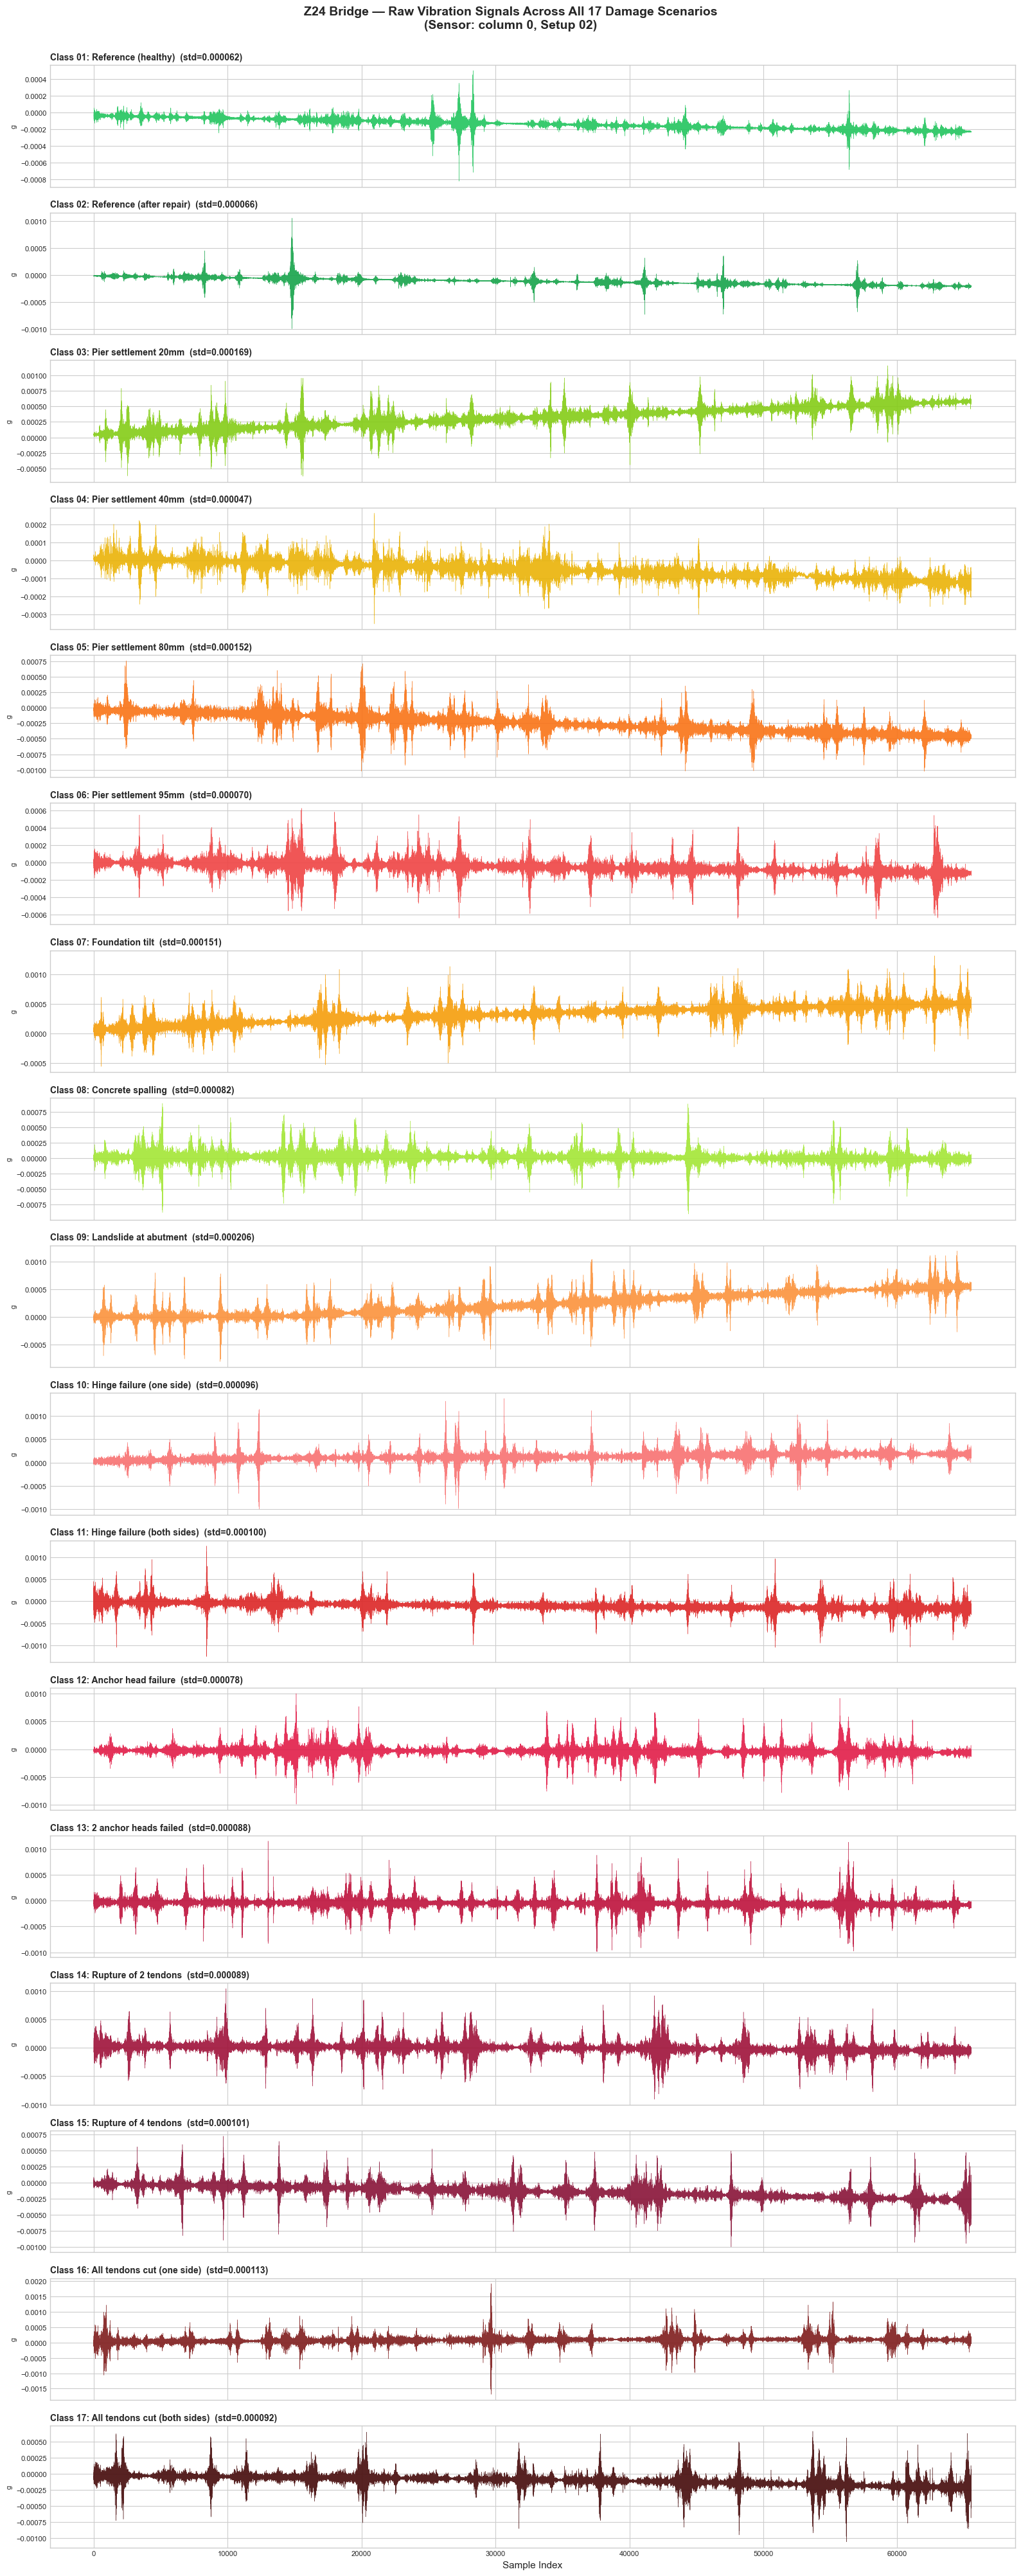

📊 Saved: fig_all_17_classes.png


In [35]:
# Cell 16d: One signal from EVERY damage class — the full progression

fig, axes = plt.subplots(17, 1, figsize=(16, 40), sharex=True)

for i, cls in enumerate(sorted(class_samples.keys())):
    signal = class_samples[cls]['data'][:, 0]
    sensor = class_samples[cls]['labels'][0].strip()
    color = severity_colors[cls]
    
    axes[i].plot(signal, linewidth=0.3, color=color, alpha=0.9)
    axes[i].set_ylabel('g', fontsize=8)
    axes[i].set_title(f'Class {cls:02d}: {damage_names[cls]}  (std={signal.std():.6f})',
                      fontsize=10, fontweight='bold', loc='left')
    axes[i].tick_params(labelsize=8)

axes[-1].set_xlabel('Sample Index', fontsize=11)
fig.suptitle('Z24 Bridge — Raw Vibration Signals Across All 17 Damage Scenarios\n(Sensor: column 0, Setup 02)',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('fig_all_17_classes.png', dpi=200, bbox_inches='tight')
plt.show()
print("📊 Saved: fig_all_17_classes.png")

C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\3777397974.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class,
C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\3777397974.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class,
C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\3777397974.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class,
C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\3777397974.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_label

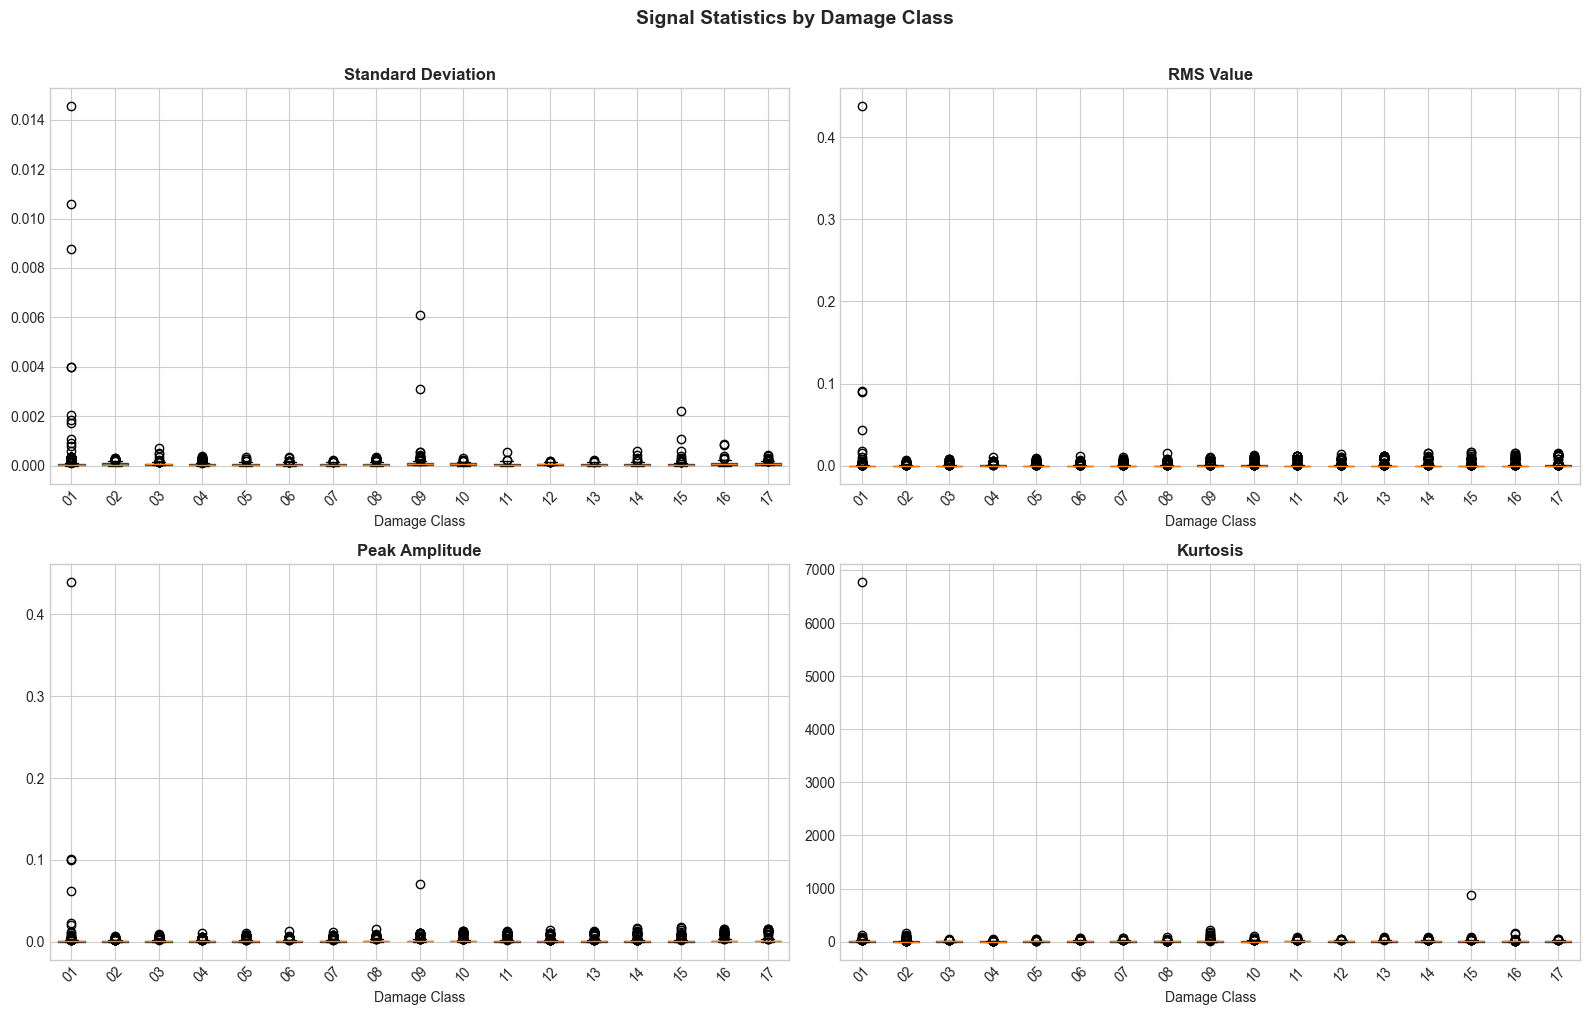

📊 Saved: fig_statistics_boxplots.png


In [36]:
# Cell 16e: Statistical features across damage classes
#
# Shows how RMS, std, peak amplitude, and kurtosis change with damage

from scipy.stats import kurtosis

# Compute stats for every sample
stats_list = []
for i in range(len(X_all)):
    signal = X_all[i]
    stats_list.append({
        'class': y_all[i],
        'std': signal.std(),
        'rms': np.sqrt(np.mean(signal**2)),
        'peak': np.max(np.abs(signal)),
        'kurtosis': kurtosis(signal),
    })

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['std', 'rms', 'peak', 'kurtosis']
titles = ['Standard Deviation', 'RMS Value', 'Peak Amplitude', 'Kurtosis']

for ax, metric, title in zip(axes.flat, metrics, titles):
    data_by_class = []
    for cls in sorted(set(y_all)):
        values = [s[metric] for s in stats_list if s['class'] == cls]
        data_by_class.append(values)
    
    bp = ax.boxplot(data_by_class, 
                    labels=[f'{c:02d}' for c in sorted(set(y_all))],
                    patch_artist=True, widths=0.6)
    
    for patch, cls in zip(bp['boxes'], sorted(set(y_all))):
        patch.set_facecolor(severity_colors[cls])
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Damage Class')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Signal Statistics by Damage Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_statistics_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()
print("📊 Saved: fig_statistics_boxplots.png")

C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\2769622740.py:46: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\2769622740.py:46: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\2769622740.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('fig_frequency_analysis.png', dpi=200, bbox_inches='tight')
C:\Users\Arihant Bisen\AppData\Local\Temp\ipykernel_1812\2769622740.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig('fig_frequency_analysis.png', dpi=200, bbox_inches='tight')
C:\Users\Arihant Bisen\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Arihant Bisen\

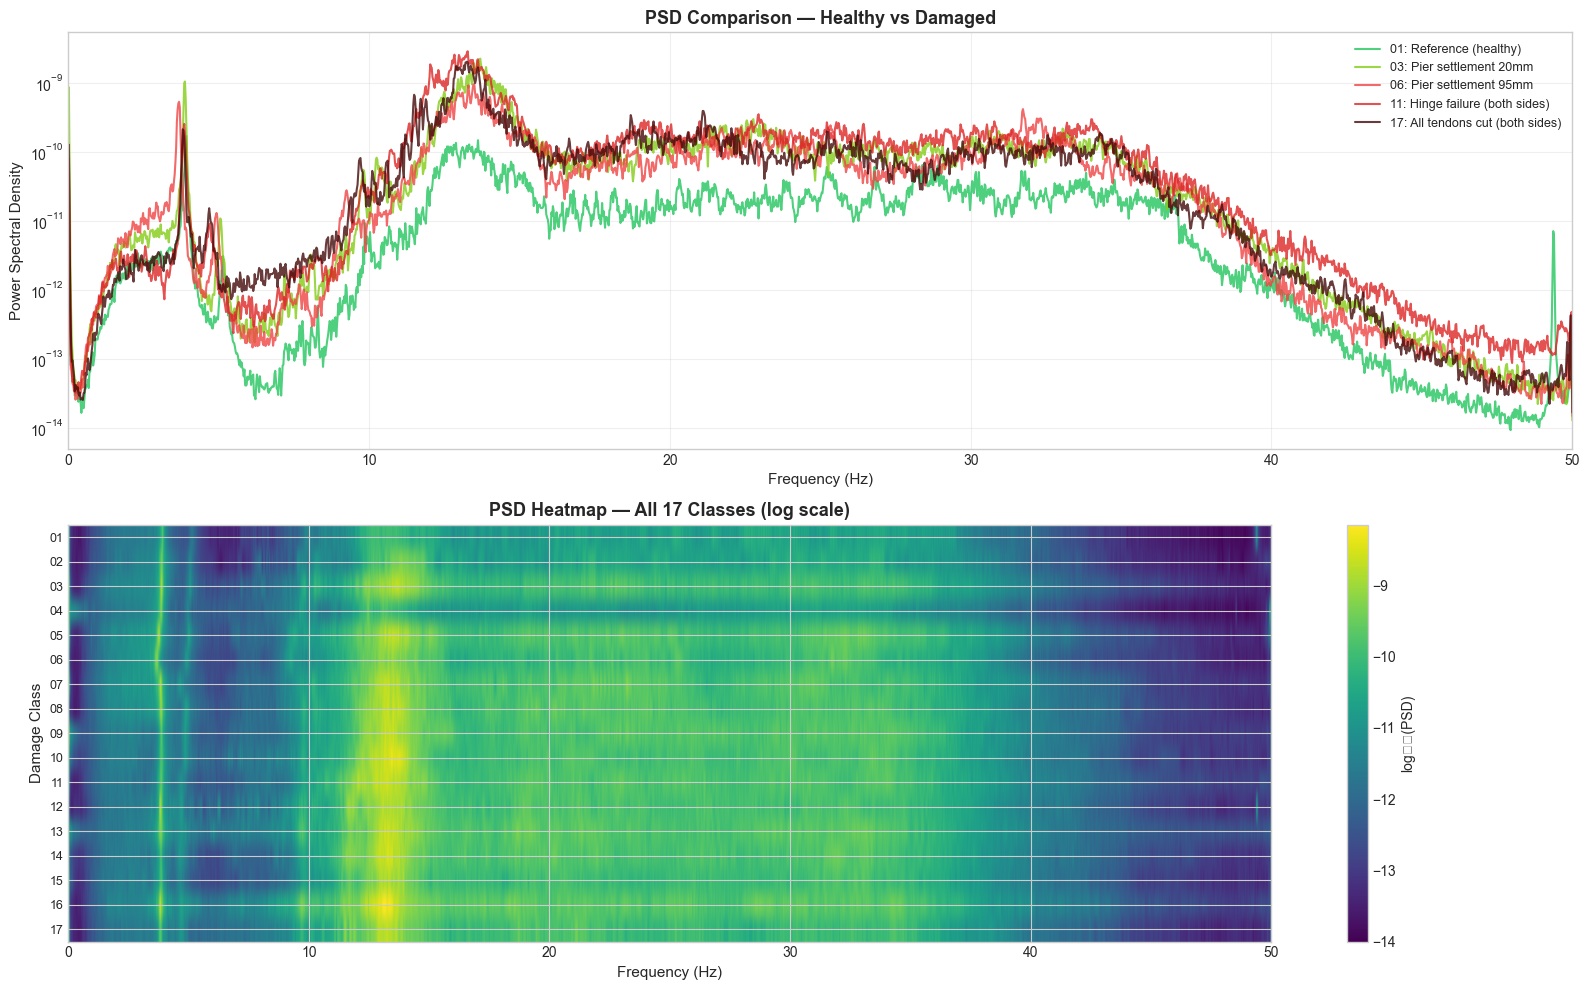

📊 Saved: fig_frequency_analysis.png


In [37]:
# Cell 16f: Power Spectral Density — how damage shifts the frequencies
#
# WHY: Damage changes the bridge's natural frequencies. This is the
#      fundamental principle behind vibration-based SHM.

from scipy.signal import welch

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Selected classes overlaid
show_classes = [1, 3, 6, 11, 17]
for cls in show_classes:
    signal = class_samples[cls]['data'][:, 0]
    freqs, psd = welch(signal, fs=100.0, nperseg=4096, noverlap=2048)
    
    axes[0].semilogy(freqs, psd, linewidth=1.5, color=severity_colors[cls], 
                     alpha=0.8, label=f'{cls:02d}: {damage_names[cls]}')

axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('Power Spectral Density', fontsize=11)
axes[0].set_title('PSD Comparison — Healthy vs Damaged', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 50)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Heatmap of PSD across all 17 classes
psd_matrix = []
for cls in sorted(class_samples.keys()):
    signal = class_samples[cls]['data'][:, 0]
    freqs, psd = welch(signal, fs=100.0, nperseg=4096, noverlap=2048)
    psd_matrix.append(psd)

psd_matrix = np.array(psd_matrix)
freq_mask = freqs <= 50  # Only show up to 50 Hz

im = axes[1].imshow(np.log10(psd_matrix[:, freq_mask] + 1e-15), 
                     aspect='auto', cmap='viridis',
                     extent=[0, 50, 17.5, 0.5])
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Damage Class', fontsize=11)
axes[1].set_title('PSD Heatmap — All 17 Classes (log scale)', fontsize=13, fontweight='bold')
axes[1].set_yticks(range(1, 18))
axes[1].set_yticklabels([f'{c:02d}' for c in range(1, 18)], fontsize=9)
plt.colorbar(im, ax=axes[1], label='log₁₀(PSD)')

plt.tight_layout()
plt.savefig('fig_frequency_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("📊 Saved: fig_frequency_analysis.png")

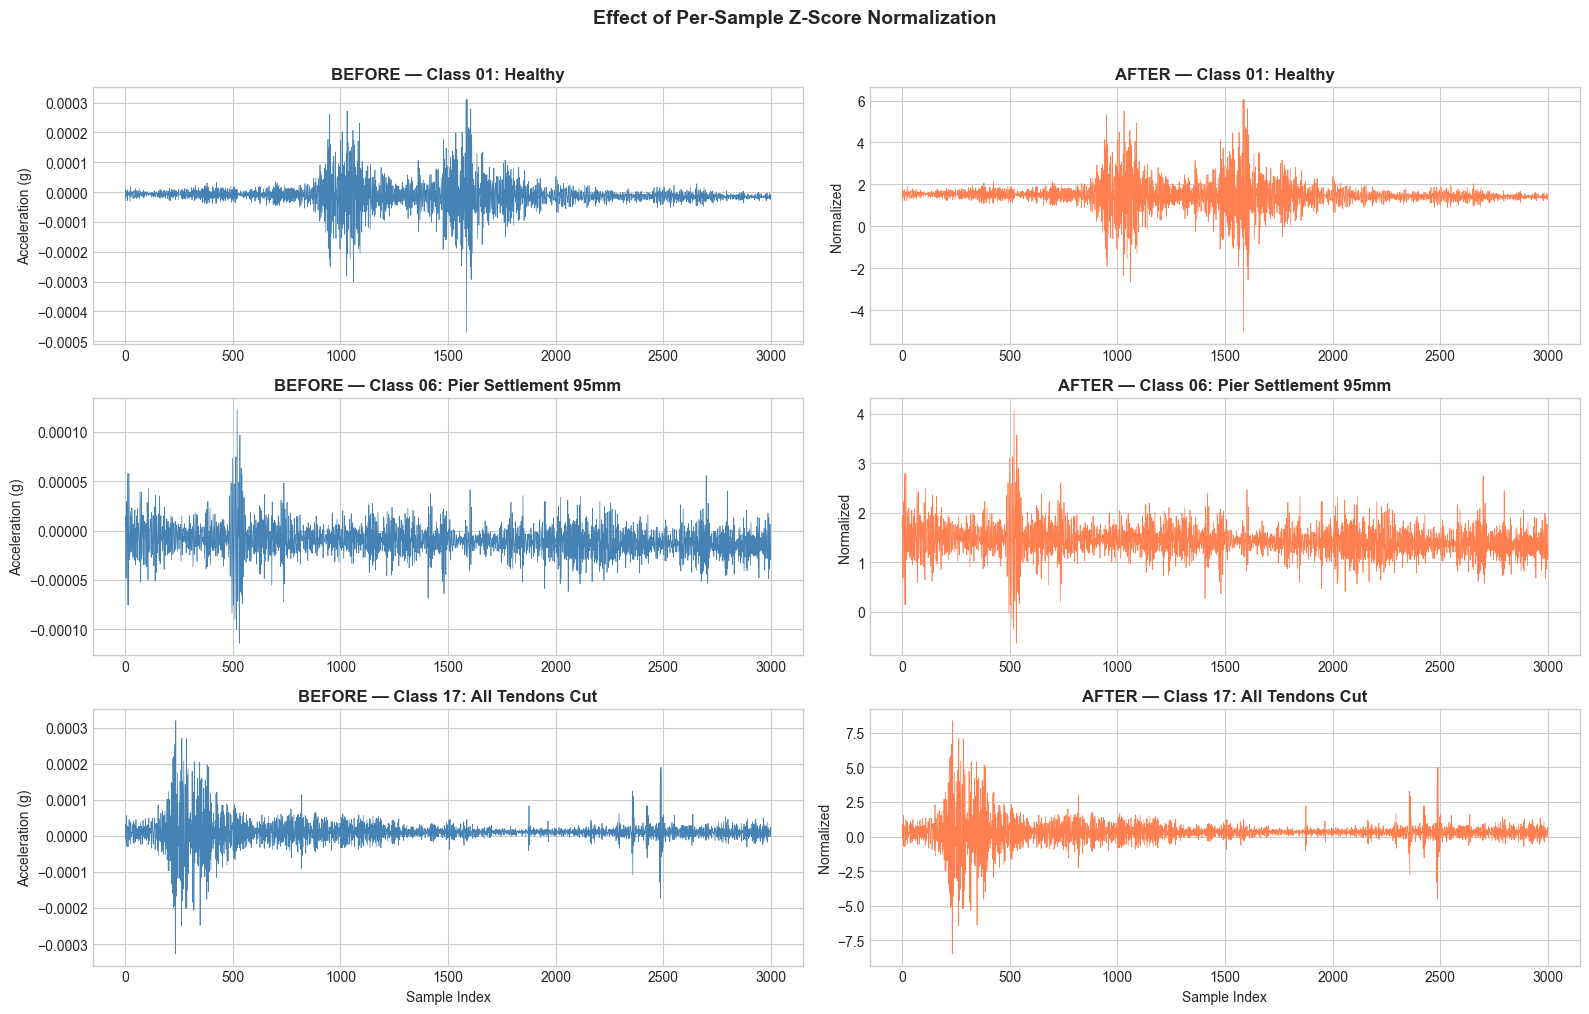

📊 Saved: fig_normalization_comparison.png


In [38]:
# Cell 16g: Before vs After normalization — 3 different classes

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

sample_classes = [1, 6, 17]
sample_names = ['Healthy', 'Pier Settlement 95mm', 'All Tendons Cut']

for row, (cls, name) in enumerate(zip(sample_classes, sample_names)):
    # Find a training sample from this class
    idx = np.where(y_train == cls)[0][0]
    
    raw = X_train[idx]
    normed = X_train_norm[idx]
    
    axes[row, 0].plot(raw[:3000], linewidth=0.5, color='steelblue')
    axes[row, 0].set_title(f'BEFORE — Class {cls:02d}: {name}', fontweight='bold')
    axes[row, 0].set_ylabel('Acceleration (g)')
    
    axes[row, 1].plot(normed[:3000], linewidth=0.5, color='coral')
    axes[row, 1].set_title(f'AFTER — Class {cls:02d}: {name}', fontweight='bold')
    axes[row, 1].set_ylabel('Normalized')

axes[2, 0].set_xlabel('Sample Index')
axes[2, 1].set_xlabel('Sample Index')

fig.suptitle('Effect of Per-Sample Z-Score Normalization', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_normalization_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("📊 Saved: fig_normalization_comparison.png")

In [39]:
# Cell 17: Save processed data so we don't have to reload 152 files every time
#
# WHY: Loading and processing took a while. Save the result so that
#      in 02_wavenet_training.ipynb you can just load this file
#      and start training immediately.

save_path = DATA_ROOT / "processed"
save_path.mkdir(exist_ok=True)

np.savez_compressed(
    save_path / "z24_processed.npz",
    X_train=X_train_final,
    X_val=X_val_final,
    X_test=X_test_final,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
)

# Also save the metadata and normalization info
import json

meta_save = {
    'total_samples': len(X_all),
    'signal_length': X_train_final.shape[1],
    'num_classes': len(set(y_all)),
    'classes': sorted(set(int(c) for c in y_all)),
    'damage_names': damage_names,
    'train_setups': train_setups,
    'val_setups': val_setups,
    'test_setups': test_setups,
    'train_size': len(X_train_final),
    'val_size': len(X_val_final),
    'test_size': len(X_test_final),
    'normalization': 'per_sample_zscore',
    'excluded_files': ['03setup01.mat'],
    'data_source': 'avt only',
}

with open(save_path / "z24_metadata.json", "w") as f:
    json.dump(meta_save, f, indent=2)

# Check file size
file_size = (save_path / "z24_processed.npz").stat().st_size / (1024**3)
print(f"✅ Saved to: {save_path}")
print(f"   z24_processed.npz  ({file_size:.2f} GB)")
print(f"   z24_metadata.json")
print(f"\nIn your next notebook, load with:")
print(f'   data = np.load(r"{save_path / "z24_processed.npz"}")')
print(f'   X_train = data["X_train"]')
print(f'   y_train = data["y_train"]')

✅ Saved to: C:\Users\Arihant Bisen\Documents\data\processed
   z24_processed.npz  (0.82 GB)
   z24_metadata.json

In your next notebook, load with:
   data = np.load(r"C:\Users\Arihant Bisen\Documents\data\processed\z24_processed.npz")
   X_train = data["X_train"]
   y_train = data["y_train"]
